In [1]:
# The SEC result is from Agilent
# The ImportAgilentFID.m is a Matlab script to read the Agilent FID file.
# The source of the ImportAgilentFID.m is from:
# https://github.com/chemplexity/chromatography/blob/master/Development/File%20Conversion/ImportAgilentFID.m

In [3]:
import os
import time
import copy
import random
import datetime
import itertools
import statistics
import matplotlib

from os.path import dirname, join as pjoin

import scipy.io
import pandas as pd
import numpy as np
from numpy import arange
from matplotlib import cm
import matplotlib.pyplot as plt
from pandas import read_csv

from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as path_effects
import matplotlib.patches as mpatches
import matplotlib.animation as animation

In [4]:
import h5py

In [5]:
import seaborn as sns

In [6]:
from sec_utils.sec_utils import read_mat, filter_by_sample_name, filter_by_abs_wl

In [6]:
def df_filter(df, cutoff_date, abs_wl_values):
    """
    Filters the input DataFrame based on several criteria:
    - Records after a specified cutoff date.
    - Specific absorbance wavelength (abs_wl) values.
    - Sample name validity (not NA, not empty, not 'blank', not containing 'wash').

    Args:
        df (pd.DataFrame): The DataFrame to be filtered. 
                           It should contain 'datetime', 'abs_wl', and 'sample_name' columns.
        cutoff_date (datetime.datetime): The cutoff date. Records older than this date will be removed.
                                         Note: This argument is currently overwritten within the function.
        abs_wl_values (list): A list of strings representing absorbance wavelengths to keep.
                              Note: This argument is currently overwritten within the function.

    Returns:
        pd.DataFrame: The filtered DataFrame.
    """

    # Filter records to include only those after the specified cutoff_date.
    df = df[(df['datetime'] > cutoff_date)]

    # Apply filtering based on sample_name criteria using the helper function.
    df = filter_by_sample_name(df)

    # Apply filtering based on abs_wl criteria using the helper function and the specified abs_wl_values.
    df = filter_by_abs_wl(df, abs_wl_values)

    return df

In [7]:
df = read_mat('./input/20250530_sec_result_total.mat')

cutoff_date = datetime.datetime(2021, 8, 15)
abs_wl_values = ["280", "260", "230", "214", "488", "587"]

df_filtered = df_filter(df, cutoff_date, abs_wl_values)

In [8]:
df_filtered

,datetime,abs_wl,sample_name,time,signal
41096,2021-08-19 13:18:48,A280,BSA,"[0.002916666666666667, 0.009583333333333334, 0...","[0.041961669921875, 0.040531158447265625, 0.04..."
41097,2021-08-19 13:18:48,A230,BSA,"[0.002916666666666667, 0.009583333333333334, 0...","[0.0209808349609375, 0.02193450927734375, 0.02..."
41098,2021-08-19 13:18:48,A488,BSA,"[0.002916666666666667, 0.009583333333333334, 0...","[-0.011444091796875, -0.010013580322265625, -0..."
41099,2021-08-19 13:18:48,A587,BSA,"[0.002916666666666667, 0.009583333333333334, 0...","[0.00762939453125, 0.008106231689453125, 0.007..."
41100,2021-08-19 13:18:48,A260,BSA,"[0.002916666666666667, 0.009583333333333334, 0...","[-0.00762939453125, -0.005245208740234375, -0...."
...,...,...,...,...,...
59511,2025-01-13 17:10:15,A260,dArmRP_C3_frac_D03,"[0.005833333333333334, 0.0125, 0.0191666666666...","[-0.051975250244140625, -0.024318695068359375,..."
59512,2025-01-13 17:10:15,A230,dArmRP_C3_frac_D03,"[0.005833333333333334, 0.0125, 0.0191666666666...","[0.03528594970703125, 0.07009506225585938, 0.0..."
59513,2025-01-13 17:10:15,A488,dArmRP_C3_frac_D03,"[0.005833333333333334, 0.0125, 0.0191666666666...","[-0.00858306884765625, -0.0133514404296875, 0...."
59515,2025-01-13 17:10:15,A587,dArmRP_C3_frac_D03,"[0.005833333333333334, 0.0125, 0.0191666666666...","[-0.07581710815429688, -0.058650970458984375, ..."


In [9]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8377 entries, 41096 to 59516
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     8377 non-null   datetime64[ns]
 1   abs_wl       8377 non-null   object        
 2   sample_name  8377 non-null   object        
 3   time         8377 non-null   object        
 4   signal       8377 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 392.7+ KB


In [10]:
def process_df(df_input):
    # It's good practice to work on a copy to avoid modifying the original DataFrame unexpectedly.
    df = df_input.copy()

    # The following lines for 'abs_wl' processing and filtering are kept commented
    # as they were in the provided reference function.
    # If they are needed, they can be uncommented.
    # df['abs_wl']=df.apply(lambda row: SigDesc_dict[row['abs_wl']], axis=1)
    # df = df[~df.abs_wl.isin(["587_610"])]

    # 1. Explode 'time' and 'signal' columns first.
    # The 'time' and 'signal' columns in the input DataFrame are expected to be array-like (e.g., lists or NumPy arrays).
    
    # Create a temporary column containing pairs of (time, signal)
    # This will be used for the explode operation.
    df["time_and_signal_pairs"] = df.apply(lambda row: list(zip(row["time"], row["signal"])), axis=1)
    
    # Explode the DataFrame. Rows will be duplicated for each pair in 'time_and_signal_pairs'.
    # Other columns (like 'datetime', 'abs_wl', 'sample_name') will be duplicated accordingly.
    df = df.explode("time_and_signal_pairs")
    
    # Split the 'time_and_signal_pairs' tuple back into 'time' and 'signal' columns.
    # These new 'time' and 'signal' columns will contain scalar values.
    # Handle cases where 'time_and_signal_pairs' might be NaN (e.g., if original lists were empty)
    df["time"] = df["time_and_signal_pairs"].apply(lambda x: x[0] if pd.notna(x) else np.nan)
    df["signal"] = df["time_and_signal_pairs"].apply(lambda x: x[1] if pd.notna(x) else np.nan)
    
    # Remove the temporary helper column.
    df = df.drop(columns=["time_and_signal_pairs"])
    
    # Reset the index of the DataFrame after exploding.
    df = df.reset_index(drop=True)

    # 2. Normalize the 'signal' column based on conditional time ranges.
    group_cols = ['datetime', 'abs_wl', 'sample_name']
    
    # Calculate the maximum time for each group to determine normalization strategy
    df['max_time_in_group'] = df.groupby(group_cols)['time'].transform('max')
    
    # Calculate max signal in the [4, 9] time range for each group
    # Create a temporary column with signals only in the 4-9 time range, NaN otherwise
    df['temp_signal_4_9'] = df['signal'].where((df['time'] >= 4) & (df['time'] <= 9))
    df['max_signal_4_9'] = df.groupby(group_cols)['temp_signal_4_9'].transform('max')
    
    # Calculate max signal in the [16, 36] time range for each group
    # Create a temporary column with signals only in the 16-36 time range, NaN otherwise
    df['temp_signal_16_36'] = df['signal'].where((df['time'] >= 10) & (df['time'] <= 40))
    df['max_signal_16_36'] = df.groupby(group_cols)['temp_signal_16_36'].transform('max')
    
    # Determine the actual normalization divisor based on max_time_in_group
    df['norm_divisor'] = np.where(
        df['max_time_in_group'] < 30,
        df['max_signal_4_9'],
        df['max_signal_16_36']
    )
    
    # Perform the normalization
    df['signal_norm'] = df['signal'] / df['norm_divisor']
    
    # Replace any infinity values (resulting from division by zero if signal was non-zero) with NaN
    df['signal_norm'].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Clean up temporary columns used for normalization
    df = df.drop(columns=[
        'max_time_in_group', 
        'temp_signal_4_9', 'max_signal_4_9',
        'temp_signal_16_36', 'max_signal_16_36',
        'norm_divisor'
    ])

    return df

In [11]:
abs_wl_values = sorted(df_filtered['abs_wl'].unique().tolist())

df_processed_list = []

for abs_wl in abs_wl_values:
    df_sub = df_filtered[df_filtered['abs_wl'] == abs_wl]
    df_sub_processed = process_df(df_sub)
    df_processed_list.append(df_sub_processed)

df_processed = pd.concat(df_processed_list, ignore_index=True)

/tmp/ipykernel_3232992/3609313623.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['signal_norm'].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_3232992/3609313623.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [12]:
df_processed.to_csv('./output/processed_sec_data.csv.gzip', index=False, compression='gzip')

In [25]:
df_processed = pd.read_csv('./output/processed_sec_data.csv.gzip', compression='gzip')
df_processed['datetime'] = pd.to_datetime(df_processed['datetime'])

In [ ]:
import os

df_280 = df_processed[df_processed['abs_wl'] == 'A280']

chunk_size = 8
unique_datetimes = df_280['datetime'].unique()
chunks = [df_280[df_280['datetime'].isin(unique_datetimes[i:i + chunk_size])] 
          for i in range(0, len(unique_datetimes), chunk_size)]

# Plot each chunk
for chunk in chunks:
    if chunk.empty: # Skip if the chunk has no data
        plt.close() # Close the figure if it was created by a previous iteration's error or skip
        continue

    plt.figure(figsize=(16, 10))
    ax = plt.subplot(111)
    
    # Iterate over each unique (datetime, sample_name) combination within the chunk
    # This ensures each line on the plot corresponds to one specific sample run
    for (run_datetime, sample_name), sample_run_data in chunk.groupby(['datetime', 'sample_name']):
        # Format the datetime for the label. Using a common format.
        datetime_str = run_datetime.strftime('%Y-%m-%d %H:%M')
        label = f"{sample_name} ({datetime_str})"
        
        ax.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6)
    
    ax.set_xlabel("Time (min)", fontsize=14)
    ax.set_ylabel("Signal (normalized)", fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend only if there are lines plotted
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        # Pandas groupby sorts keys, so legend items should be somewhat ordered.
        # Adjust fontsize if labels are too crowded.
        ax.legend(fontsize=12) 
        
    plt.grid(False)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(-0.5, 1.1) # Retain existing y-limits
    plt.tight_layout()
    
    # Ensure the ./temp directory exists
    # os.path.join can be used for better path construction if preferred
    os.makedirs('./temp', exist_ok=True) 
    
    # Save the plot using the datetime of the first row in the chunk for the filename
    # This filename identifies the chunk, not the individual lines within it.
    first_datetime_in_chunk_str = chunk.iloc[0]['datetime'].strftime('%Y%m%d_%H%M%S')
    plt.savefig(f'./temp/plot_chunk_{first_datetime_in_chunk_str}.png', dpi=600)
    plt.close() # Close the figure to free up memory

In [12]:
df_extended = df_processed.copy()
# Filter for sample_name containing "Na4Q6" or "Na4_M6Q6"
condition_contains_target = (
    df_extended['sample_name'].str.contains("Na4Q6", na=False) |
    df_extended['sample_name'].str.contains("Na4_M6Q6", na=False)
)

# List of substrings to exclude
substrings_to_exclude = ["__", "EGFP", "mCherry", "KR", "cc", "MBP", "H12", 'Na4Q6M3_50mM']

# Initialize a combined condition for exclusion with True (all rows pass initially)
combined_condition_not_contains = pd.Series(True, index=df_extended.index)

# Sequentially apply NOT CONTAINS conditions
for sub_str in substrings_to_exclude:
    combined_condition_not_contains &= ~df_extended['sample_name'].str.contains(sub_str, na=False)

# Combine all conditions
df_extended = df_extended[condition_contains_target & combined_condition_not_contains]


In [13]:
# Group by 'datetime' and calculate the maximum time for each group
max_time_per_datetime = df_extended.groupby('datetime')['time'].max()

# Identify the datetimes where the maximum time is greater than or equal to 20
valid_datetimes = max_time_per_datetime[max_time_per_datetime >= 20].index

# Filter the DataFrame to keep only rows with valid datetimes
df_extended = df_extended[df_extended['datetime'].isin(valid_datetimes)]

df_extended

,datetime,abs_wl,sample_name,time,signal,signal_norm
1614277,2022-05-25 08:34:32,A214,Na4Q6M6Q6M6Q6A,0.004783,0.064373,0.000049
1614278,2022-05-25 08:34:32,A214,Na4Q6M6Q6M6Q6A,0.011450,0.103474,0.000078
1614279,2022-05-25 08:34:32,A214,Na4Q6M6Q6M6Q6A,0.018117,0.127316,0.000096
1614280,2022-05-25 08:34:32,A214,Na4Q6M6Q6M6Q6A,0.024783,0.145435,0.000110
1614281,2022-05-25 08:34:32,A214,Na4Q6M6Q6M6Q6A,0.031450,0.172615,0.000130
...,...,...,...,...,...,...
44170071,2023-07-25 05:08:40,A587,Na4_M6Q6_7MA,74.972283,0.109196,0.066473
44170072,2023-07-25 05:08:40,A587,Na4_M6Q6_7MA,74.978950,0.102997,0.062700
44170073,2023-07-25 05:08:40,A587,Na4_M6Q6_7MA,74.985617,0.100613,0.061248
44170074,2023-07-25 05:08:40,A587,Na4_M6Q6_7MA,74.992283,0.104904,0.063861


In [22]:
df_extended= df_processed.copy()
df_extended = df_processed[
    (df_processed['datetime'] >= pd.to_datetime('2022-05-01')) &
    (df_processed['datetime'] <= pd.to_datetime('2022-12-14')) &
    (df_processed['abs_wl'].isin(['A280', 'A488']))
]

In [30]:
name_2_module_count = {
    'Na4Q6A': 6,
    'Na4Q6M6Q6A': 18,
    'Na4Q6M6Q6M6Q6A': 30,
    'Na4_M6Q6_4MA': 49,
    'Na4_M6Q6_5MA': 61,
    'Na4_M6Q6_7MA': 85,
    'Na4M6Q6_7MA': 85,
}

df_extended['module_count'] = df_extended['sample_name'].map(name_2_module_count)

In [26]:
#df_extended = df_extended[df_extended['abs_wl'] == 'A280']
#df_extended = df_extended[df_extended['sample_name'].isin(['Na4Q6A','Na4Q6M6Q6A','Na4Q6M6Q6M6Q6A','Na4_M6Q6_5MA','Na4_M6Q6_4MA','Na4_M6Q6_7MA'])]
#print(df_extended.sample_name.unique())

df_extended= df_processed.copy()

# Define the conditions for rows to be removed
condition1 = (df_extended['sample_name'] == 'Na4Q6A') & (df_extended['datetime'].dt.date == pd.to_datetime('2022-05-25').date())
condition2 = (df_extended['sample_name'] == 'Na4Q6M6Q6A') & (df_extended['datetime'].dt.date == pd.to_datetime('2022-09-11').date())
condition3 = (df_extended['sample_name'] == 'Na4Q6M6Q6M6Q6A') & (df_extended['datetime'].dt.date == pd.to_datetime('2022-05-25').date())
condition4 = (df_extended['sample_name'] == 'Na4_M6Q6_4MA') & (df_extended['datetime'].dt.date == pd.to_datetime('2022-11-24').date())
condition5 = (df_extended['sample_name'] == 'Na4_M6Q6_5MA') & (df_extended['datetime'].dt.date == pd.to_datetime('2022-11-24').date())
condition6 = (df_extended['sample_name'] == 'Na4M6Q6_7MA') & (df_extended['datetime'].dt.date == pd.to_datetime('2022-12-15').date())
# Combine the conditions using OR (rows that satisfy any of these conditions will be marked True)
rows_to_remove = condition1 | condition2 | condition3 | condition4 | condition5 | condition6

# Remove the rows by keeping only those that do NOT satisfy the combined condition
df_extended = df_extended[rows_to_remove]

df_extended.sample_name.unique()

array(['Na4Q6M6Q6M6Q6A', 'Na4Q6A', 'Na4Q6M6Q6A', 'Na4_M6Q6_5MA',
       'Na4_M6Q6_4MA', 'Na4M6Q6_7MA'], dtype=object)

In [ ]:
name_2_module_count = {
    'Na4Q6A': 6,
    'Na4Q6M6Q6A': 18,
    'Na4Q6M6Q6M6Q6A': 30,
    'Na4_M6Q6_4MA': 49,
    'Na4_M6Q6_5MA': 61,
    'Na4_M6Q6_7MA': 85,
    'Na4M6Q6_7MA': 85,
}

df_extended['module_count'] = df_extended['sample_name'].map(name_2_module_count)

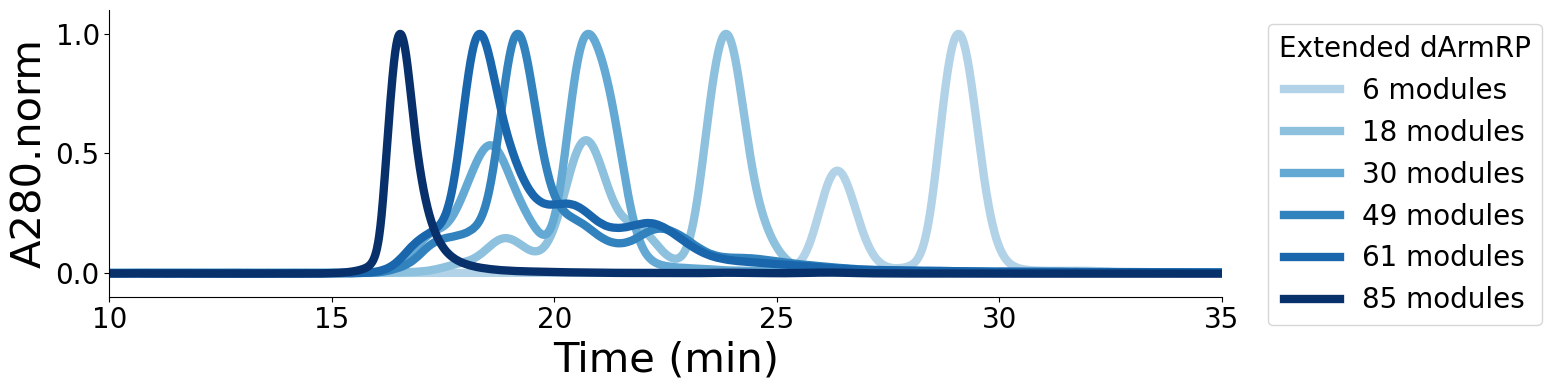

In [88]:
from matplotlib import cm
from matplotlib.colors import Normalize

df_extended_280 = df_extended[df_extended['abs_wl'] == 'A280']

plt.figure(figsize=(16, 4))
ax = plt.subplot(111)

fontsize = 20

# Sort the DataFrame by 'module_count' and 'time' before grouping
df_extended_sorted = df_extended_280.sort_values(by=['module_count'])

# Normalize module_count values for color mapping
norm = Normalize(vmin=-30, vmax=max(name_2_module_count.values()))
colormap = cm.Blues

# Iterate over each unique module_count, sorted by module_count
for module_count, sample_run_data in df_extended_sorted.groupby('module_count'):
    sample_run_data = sample_run_data.sort_values(by=['time'])
    # Format the datetime for the label
    label = f"{module_count} modules"
    
    # Map module_count to a color
    color = colormap(norm(module_count))
    
    # Plot the curve
    ax.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6, color=color)

ax.set_xlabel("Time (min)", fontsize=fontsize * 1.5)
ax.set_ylabel("A280.norm", fontsize=fontsize * 1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend with a title
handles, labels = ax.get_legend_handles_labels()
if handles:
    legend = ax.legend(handles, labels, fontsize=fontsize, loc='upper right', bbox_to_anchor=(1.3, 1), title="Extended dArmRP")
    legend.get_title().set_fontsize(fontsize)  # Set the title font size

plt.grid(False)
plt.xticks(fontsize=fontsize)
plt.yticks([0, 0.5, 1], fontsize=fontsize)  # Set y-ticks
plt.tight_layout()
plt.ylim(-0.1, 1.1)  # Retain existing y-limits
plt.xlim(10, 35)     # Retain existing x-limits
# Save the plot
plt.savefig('./output/sec_plot_by_module_count2.pdf', format='pdf')
plt.show()


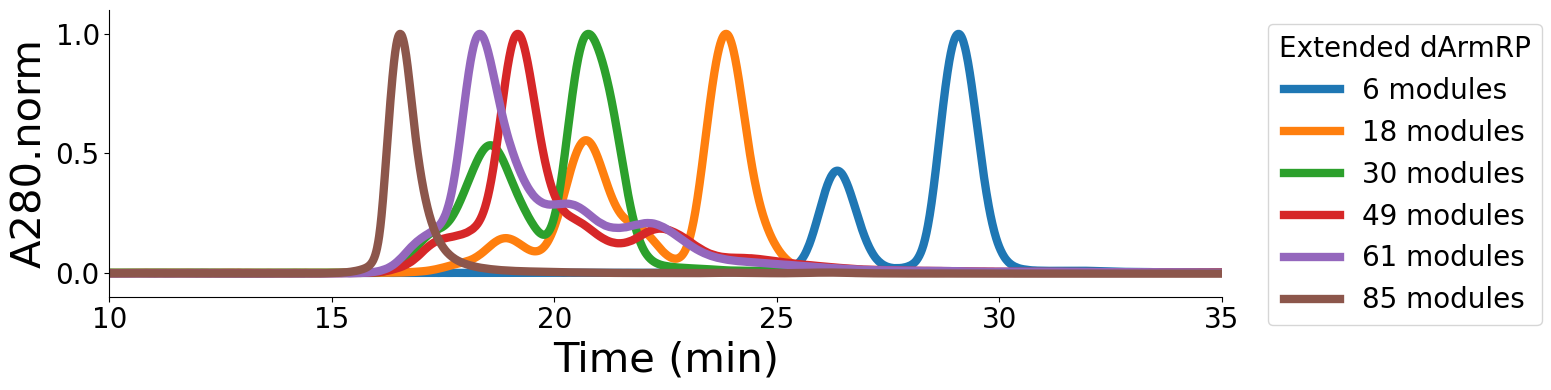

In [69]:
df_extended_280 = df_extended[df_extended['abs_wl'] == 'A280']

plt.figure(figsize=(16, 4))
ax = plt.subplot(111)

fontsize = 20

# Sort the DataFrame by 'module_count' and 'time' before grouping
df_extended_sorted = df_extended_280.sort_values(by=['module_count'])

# Iterate over each unique module_count, sorted by module_count
for module_count, sample_run_data in df_extended_sorted.groupby('module_count'):

    sample_run_data = sample_run_data.sort_values(by=['time'])
    # Format the datetime for the label
    label = f"{module_count} modules"
    
    # Plot the curve
    ax.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6)

ax.set_xlabel("Time (min)", fontsize=fontsize*1.5)
ax.set_ylabel("A280.norm", fontsize=fontsize*1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend with a title
handles, labels = ax.get_legend_handles_labels()
if handles:
    legend = ax.legend(handles, labels, fontsize=fontsize, loc='upper right', bbox_to_anchor=(1.3, 1), title="Extended dArmRP")
    legend.get_title().set_fontsize(fontsize)  # Set the title font size

plt.grid(False)
plt.xticks(fontsize=fontsize)
plt.yticks([0, 0.5, 1], fontsize=fontsize)  # Set y-ticks
plt.tight_layout()
plt.ylim(-0.1, 1.1)  # Retain existing y-limits
plt.xlim(10, 35)     # Retain existing x-limits
# Save the plot
plt.savefig('./output/sec_plot_by_module_count.pdf', format='pdf')
plt.show()


In [54]:
df_7egfp= df_processed.copy()

# Define the conditions for rows to be removed
condition1 = (df_7egfp['sample_name'] == 'Na4M6Q6_7MA') & (df_7egfp['datetime'].dt.date == pd.to_datetime('2022-12-15').date())
condition2 = (df_7egfp['sample_name'] == 'Na4M6Q67MA__ARQR36BH113G124__EGFP') & (df_7egfp['datetime'] == pd.to_datetime('2022-12-15 17:47:59'))
condition3 = (df_7egfp['sample_name'] == 'EGFP') & (df_7egfp['datetime'].dt.date == pd.to_datetime('2022-11-23').date())
condition4 = (df_7egfp['sample_name'] == 'ARQR3_6B_H11_3G124') & (df_7egfp['datetime'].dt.date == pd.to_datetime('2022-11-23').date())
condition5 = (df_7egfp['sample_name'] == 'EGFP__ARQR3_6B_H11_3G124') & (df_7egfp['datetime'].dt.date == pd.to_datetime('2022-11-23').date())
# Combine the conditions using OR (rows that satisfy any of these conditions will be marked True)
rows_to_plot = condition1 | condition2 | condition3 | condition4 | condition5

# Remove the rows by keeping only those that do NOT satisfy the combined condition
df_7egfp = df_7egfp[rows_to_plot]

df_7egfp.sample_name.unique()

array(['EGFP', 'ARQR3_6B_H11_3G124', 'EGFP__ARQR3_6B_H11_3G124',
       'Na4M6Q6_7MA', 'Na4M6Q67MA__ARQR36BH113G124__EGFP'], dtype=object)

In [82]:
sample_name_2_label = {"Na4M6Q6_7MA": 'dArmRP',
                          "Na4M6Q67MA__ARQR36BH113G124__EGFP": 'dArmRP + tagged DARPin1 + EGFP',
                          "EGFP": 'EGFP',
                          "ARQR3_6B_H11_3G124": 'tagged DARPin1',
                          "EGFP__ARQR3_6B_H11_3G124": 'tagged DARPin1 + EGFP'}

extended_darmrp_sample_colors = {
    'EGFP': (34, 136, 51),  # Green
    'EGFP__ARQR3_6B_H11_3G124': (102, 204, 238),  # Cyan
    'Na4M6Q67MA__ARQR36BH113G124__EGFP': (68, 119, 170),  # Blue
    'Na4M6Q6_7MA': (204, 187, 68),  # Yellow
    'ARQR3_6B_H11_3G124': (238, 102, 119),  # Red
}

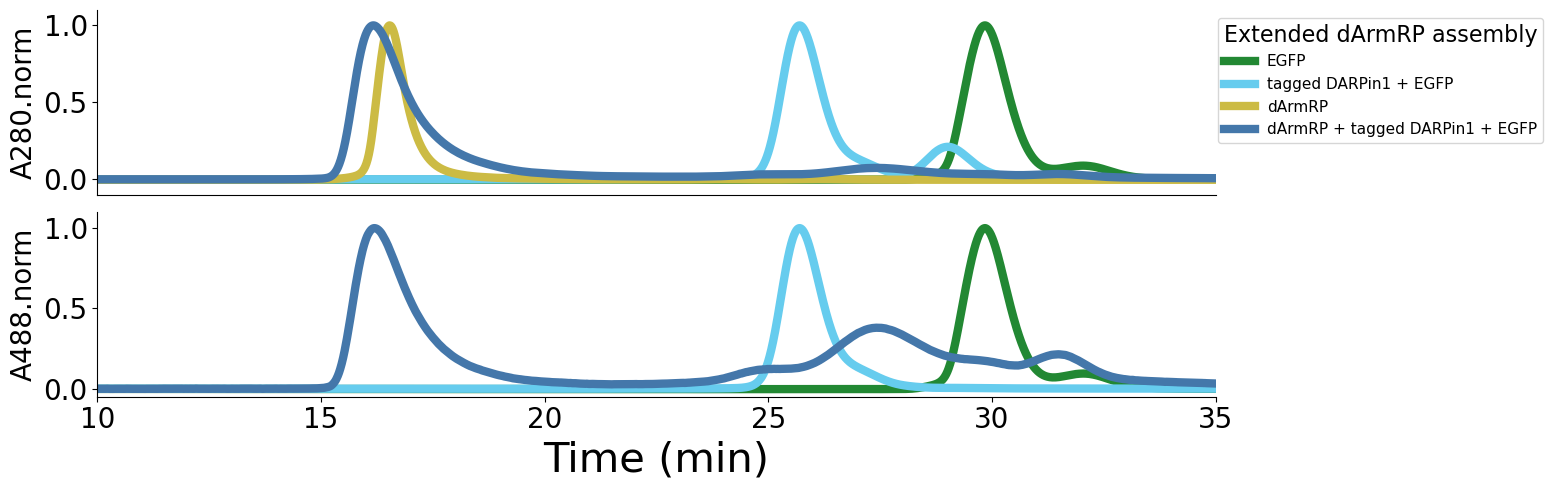

In [83]:
plt.figure(figsize=(16, 5))

fontsize = 20

df_7egfp_280 = df_7egfp[df_7egfp['abs_wl'] == 'A280']
df_7egfp_488 = df_7egfp[df_7egfp['abs_wl'] == 'A488']

sample_list_280 = ['EGFP', 'EGFP__ARQR3_6B_H11_3G124','Na4M6Q6_7MA', 
               'Na4M6Q67MA__ARQR36BH113G124__EGFP']
sample_list_488 = ['EGFP', 'EGFP__ARQR3_6B_H11_3G124', 
               'Na4M6Q67MA__ARQR36BH113G124__EGFP']

# First subplot for A280
ax1 = plt.subplot(211)  # 2 rows, 1 column, first plot
for sample_name in sample_list_280:  # Iterate in the order defined by sample_list
    sample_run_data = df_7egfp_280[df_7egfp_280['sample_name'] == sample_name]
    label = sample_name_2_label[sample_name]
    color = tuple(c / 255 for c in extended_darmrp_sample_colors[sample_name])  # Normalize RGB values to [0, 1]
    
    ax1.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6, color=color)

ax1.set_ylabel("A280.norm", fontsize=fontsize)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
handles, labels = ax1.get_legend_handles_labels()
if handles:
    legend = ax1.legend(handles, labels, fontsize=11, loc='upper right', bbox_to_anchor=(1.3, 1), title="Extended dArmRP assembly")
    legend.get_title().set_fontsize(fontsize*0.8)  # Set the title font size
ax1.grid(False)
ax1.set_xlim(10, 35)
ax1.set_ylim(-0.1, 1.1)
ax1.set_xticks([])  # Remove x-axis ticks
ax1.set_xlabel("")  # Remove x-axis label

# Second subplot for A488
ax2 = plt.subplot(212)  # 2 rows, 1 column, second plot
for sample_name in sample_list_488:  # Iterate in the order defined by triangle_samples_488
    sample_run_data = df_7egfp_488[df_7egfp_488['sample_name'] == sample_name]
    label = sample_name_2_label[sample_name]
    color = tuple(c / 255 for c in extended_darmrp_sample_colors[sample_name])  # Normalize RGB values to [0, 1]
    
    ax2.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6, color=color)

ax2.set_xlabel("Time (min)", fontsize=fontsize*1.5)
ax2.set_ylabel("A488.norm", fontsize=fontsize)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(False)
ax2.set_xlim(10, 35)
ax2.set_ylim(-0.05, 1.1)
ax2.legend().remove()  # Remove the legend

ax1.tick_params(axis='y', labelsize=fontsize)
ax2.tick_params(axis='y', labelsize=fontsize)
ax2.tick_params(axis='x', labelsize=fontsize)
plt.tight_layout()
plt.savefig('./output/sec_plot_extended_darmrp_sample_colors_combined.pdf', format='pdf')
plt.show()


In [268]:

df_processed = pd.read_csv('./output/processed_sec_data.csv.gzip', compression='gzip')
df_processed['datetime'] = pd.to_datetime(df_processed['datetime'])

In [309]:
# Filter rows where sample_name contains 'L1A' or 'L1B'
condition_contains_L1 = df_processed['sample_name'].str.contains('L1A|L1B', na=False)
df_filtered_L1 = df_processed[condition_contains_L1]

# Group by 'datetime' and calculate the maximum time for each group
max_time_per_datetime_L1 = df_filtered_L1.groupby('datetime')['time'].max()

# Identify the datetimes where the maximum time is greater than or equal to 20
valid_datetimes_L1 = max_time_per_datetime_L1[max_time_per_datetime_L1 >= 20].index

# Filter the DataFrame to keep only rows with valid datetimes
df_filtered_L1 = df_filtered_L1[df_filtered_L1['datetime'].isin(valid_datetimes_L1)]

df_filtered_L1 = df_filtered_L1[df_filtered_L1['abs_wl'] == 'A280']

#df_filtered_L1 = df_filtered_L1[df_filtered_L1['datetime'].dt.date.isin([pd.to_datetime('2023-01-11').date()])]

In [310]:
df_filtered_L1.sample_name.unique().tolist()

['L1A',
 'L1B',
 'L1A__L1B',
 'L1A_L1B_12uM_50degreeON_4MUrea',
 'L1A_L1B_12uM_RT_ON',
 'L1A_L1B_12uM_50degree_ON',
 'L1A_L1B_12uM_50degree_3h']

In [311]:
# Define the conditions for rows to be removed
condition1 = (df_filtered_L1['sample_name'] == 'L1A') & (df_filtered_L1['datetime'].dt.date == pd.to_datetime('2023-01-19').date())
condition2 = (df_filtered_L1['sample_name'] == 'L1B') & (df_filtered_L1['datetime'].dt.date == pd.to_datetime('2023-01-11').date())
condition3 = (df_filtered_L1['sample_name'] == 'L1A_L1B_12uM_RT_ON') & (df_filtered_L1['datetime'].dt.date == pd.to_datetime('2023-01-12').date())
# Combine the conditions using OR (rows that satisfy any of these conditions will be marked True)
rows_to_remove = condition1 | condition2 | condition3

# Remove the rows by keeping only those that do NOT satisfy the combined condition
df_filtered_L1 = df_filtered_L1[rows_to_remove]

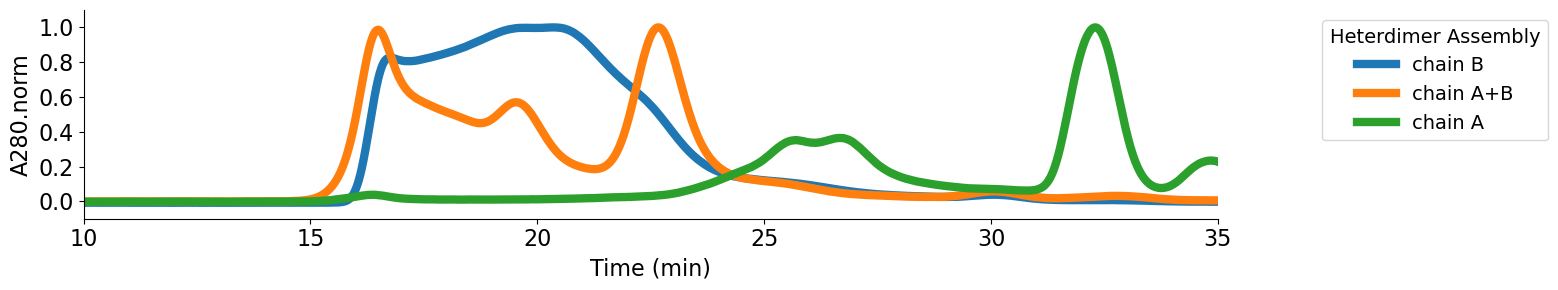

In [318]:
sample_name_2_label = {
    'L1A': 'chain A',
    'L1B': 'chain B',
    'L1A_L1B_12uM_RT_ON': 'chain A+B',
}

#df_filtered_L1 = df_filtered_L1[df_filtered_L1['sample_name'].isin(sample_name_2_label.keys())]

plt.figure(figsize=(16, 3))
ax = plt.subplot(111)

# Iterate over each unique (datetime, sample_name) combination
for (run_datetime, sample_name), sample_run_data in df_filtered_L1.groupby(['datetime', 'sample_name']):
    # Format the datetime for the label
    datetime_str = run_datetime.strftime('%Y-%m-%d %H:%M')
    label = sample_name_2_label[sample_name]
    #label = f"{sample_name} ({datetime_str})"
    
    # Plot the curve
    ax.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6)

ax.set_xlabel("Time (min)", fontsize=16)
ax.set_ylabel("A280.norm", fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend with a title
handles, labels = ax.get_legend_handles_labels()
if handles:
    legend = ax.legend(handles, labels, fontsize=14, loc='upper right', bbox_to_anchor=(1.3, 1), title="Heterdimer Assembly")
    legend.get_title().set_fontsize(14)  # Set the title font size

plt.grid(False)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.ylim(-0.1, 1.1)  # Retain existing y-limits
plt.xlim(10, 35)     # Retain existing x-limits
plt.savefig('./output/sec_plot_ladder_assembly.pdf', format='pdf')
plt.show()

In [313]:
df_processed = pd.read_csv('./output/processed_sec_data.csv.gzip', compression='gzip')
df_processed['datetime'] = pd.to_datetime(df_processed['datetime'])

In [98]:
df_processed

,datetime,abs_wl,sample_name,time,signal,signal_norm
0,2021-11-12 17:42:40,A214,pTIA_7uM_pH6,0.003333,0.053406,0.067267
1,2021-11-12 17:42:40,A214,pTIA_7uM_pH6,0.010000,0.055790,0.070270
2,2021-11-12 17:42:40,A214,pTIA_7uM_pH6,0.016667,0.057697,0.072673
3,2021-11-12 17:42:40,A214,pTIA_7uM_pH6,0.023333,0.063419,0.079880
4,2021-11-12 17:42:40,A214,pTIA_7uM_pH6,0.030000,0.074863,0.094294
...,...,...,...,...,...,...
46604169,2025-01-13 17:10:15,A587,dArmRP_C3_frac_D03,14.972500,-0.012875,0.771429
46604170,2025-01-13 17:10:15,A587,dArmRP_C3_frac_D03,14.979167,-0.019550,1.171429
46604171,2025-01-13 17:10:15,A587,dArmRP_C3_frac_D03,14.985833,-0.031948,1.914286
46604172,2025-01-13 17:10:15,A587,dArmRP_C3_frac_D03,14.992500,-0.035286,2.114286


In [89]:
# Filter rows where sample_name contains "EGFP"
condition_contains_EGFP = df_processed['sample_name'].str.contains("triangle", na=False)

# Group by 'datetime' and calculate the maximum time for each group
max_time_per_datetime_EGFP = df_processed[condition_contains_EGFP].groupby('datetime')['time'].max()

# Identify the datetimes where the maximum time is greater than 20
valid_datetimes_EGFP = max_time_per_datetime_EGFP[max_time_per_datetime_EGFP > 20].index

# Filter the DataFrame to keep only rows with valid datetimes and after 2023-07-01
df_filtered_EGFP = df_processed[
    condition_contains_EGFP & 
    df_processed['datetime'].isin(valid_datetimes_EGFP) #& 
    #(df_processed['datetime'] > pd.to_datetime('2023-07-01'))
]

df_filtered_EGFP

,datetime,abs_wl,sample_name,time,signal,signal_norm
4415604,2024-02-15 12:43:24,A214,dArmRP_homotriangle2,0.006450,-0.058651,-0.000023
4415605,2024-02-15 12:43:24,A214,dArmRP_homotriangle2,0.013117,0.030994,0.000012
4415606,2024-02-15 12:43:24,A214,dArmRP_homotriangle2,0.019783,0.159264,0.000063
4415607,2024-02-15 12:43:24,A214,dArmRP_homotriangle2,0.026450,0.308514,0.000123
4415608,2024-02-15 12:43:24,A214,dArmRP_homotriangle2,0.033117,0.377655,0.000150
...,...,...,...,...,...,...
46159214,2024-02-15 12:43:24,A587,dArmRP_homotriangle2,59.973117,0.089169,0.106069
46159215,2024-02-15 12:43:24,A587,dArmRP_homotriangle2,59.979783,0.088215,0.104935
46159216,2024-02-15 12:43:24,A587,dArmRP_homotriangle2,59.986450,0.084877,0.100964
46159217,2024-02-15 12:43:24,A587,dArmRP_homotriangle2,59.993117,0.074387,0.088486


In [90]:
df_filtered_EGFP.sample_name.unique()

array(['dArmRP_homotriangle2', 'Arm_triangle_peak1', 'Arm_triangle_peak2',
       'dArmRP_triangle_1', 'dArmRP_triangle_2', 'dArmRP_triangle_5uM',
       'dArmRP_triangle__KRKRARQRKRKR_BD__EGFP',
       'dArmRP_triangle__KRKRARQRKRKR_D2__EGFP'], dtype=object)

In [152]:
triangle_samples = ['ligand_D2_3G124_mCherry__EGFP15uM','ligand_D2_3G124_mCherry__Arm__EGFP15uM','KRKRARQRKRKR_ArmD2_3G124_mCherry', 
                    'KRKRARQRKRKR_ArmD2_3G124_mCherry__Arm', 'dArmRP_triangle_5uM', 'dArmRP_triangle__KRKRARQRKRKR_D2__EGFP', 
                    'KRKRARQRKRKR_D2_3G124_mCherry__Arm15uM', 'ligand_D2_3G124_mCherry__Arm__EGF']

triangle_samples = ['EGFP', 'dArmRP_triangle_5uM', 'ligand_D2_3G124_mCherry__EGFP15uM', 'KRKRARQRKRKR_D2_3G124_mCherry__Arm15uM', 'ligand_D2_3G124_mCherry__Arm__EGFP15uM']

In [71]:
df_triangle = df_processed.copy()

In [80]:
sample_name_2_label = {
    'EGFP': 'EGFP',
    'dArmRP_triangle_5uM': 'Triangle',
    'ligand_D2_3G124_mCherry__EGFP15uM': 'tagged DARPin2 + EGFP',
    'KRKRARQRKRKR_D2_3G124_mCherry__Arm15uM': 'Triangle + tagged DARPin2',
    'ligand_D2_3G124_mCherry__Arm__EGFP15uM': 'Triangle + tagged DARPin2 + EGFP',
}

In [73]:
triangle_sample_colors = {
    'EGFP': (34, 136, 51),  # Green
    'ligand_D2_3G124_mCherry__EGFP15uM': (102, 204, 238),  # Cyan
    'ligand_D2_3G124_mCherry__Arm__EGFP15uM': (68, 119, 170),  # Blue
    'dArmRP_triangle_5uM': (204, 187, 68),  # Yellow
    'KRKRARQRKRKR_D2_3G124_mCherry__Arm15uM': (238, 102, 119),  # Red
}


In [335]:
sample_list = ['EGFP', 'ligand_D2_3G124_mCherry__EGFP15uM', 'dArmRP_triangle_5uM', 
               'KRKRARQRKRKR_D2_3G124_mCherry__Arm15uM','ligand_D2_3G124_mCherry__Arm__EGFP15uM']

In [74]:
# Define the conditions for rows to be removed
condition1 = (df_triangle['sample_name'] == 'EGFP') & (df_triangle['datetime'].dt.date == pd.to_datetime('2022-09-03').date())
condition2 = (df_triangle['sample_name'] == 'dArmRP_triangle_5uM') & (df_triangle['datetime'].dt.date == pd.to_datetime('2023-07-18').date())
condition3 = (df_triangle['sample_name'] == 'ligand_D2_3G124_mCherry__EGFP15uM') & (df_triangle['datetime'].dt.date == pd.to_datetime('2023-07-20').date())
condition4 = (df_triangle['sample_name'] == 'ligand_D2_3G124_mCherry__Arm__EGFP15uM') & \
             (df_triangle['datetime'] >= (pd.to_datetime('2023-07-20 12:56:00') - pd.Timedelta(minutes=10))) & \
             (df_triangle['datetime'] <= (pd.to_datetime('2023-07-20 12:56:00') + pd.Timedelta(minutes=10)))
condition5 = (df_triangle['sample_name'] == 'KRKRARQRKRKR_D2_3G124_mCherry__Arm15uM') & (df_triangle['datetime'].dt.date == pd.to_datetime('2023-07-18').date())
# Combine the conditions using OR (rows that satisfy any of these conditions will be marked True)
rows_to_remove = condition1 | condition2 | condition3 | condition4 | condition5

# Remove the rows by keeping only those that do NOT satisfy the combined condition
df_triangle = df_triangle[rows_to_remove]


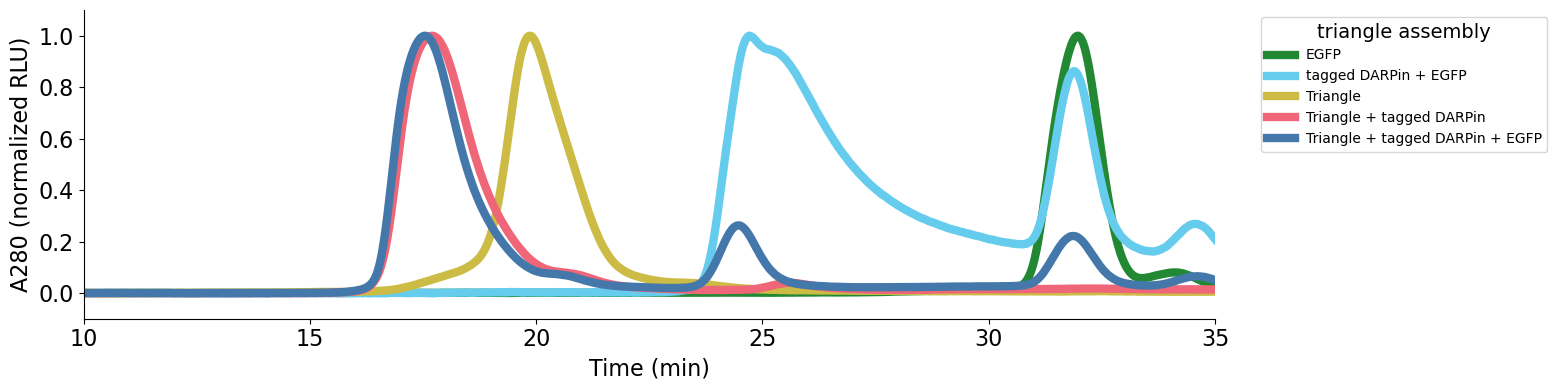

In [76]:
df_triangle_280 = df_triangle[df_triangle['abs_wl'] == 'A280']

plt.figure(figsize=(16, 4))
ax = plt.subplot(111)

# Iterate over each unique (datetime, sample_name) combination
for sample_name in sample_list:  # Iterate in the order defined by sample_list
    sample_run_data = df_triangle_280[df_triangle_280['sample_name'] == sample_name]
    label = sample_name_2_label[sample_name]
    color = tuple(c / 255 for c in triangle_sample_colors[sample_name])  # Normalize RGB values to [0, 1]
    
    # Plot the curve
    ax.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6, color=color)

ax.set_xlabel("Time (min)", fontsize=16)
ax.set_ylabel("A280 (normalized RLU)", fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend with a title
handles, labels = ax.get_legend_handles_labels()
if handles:
    legend = ax.legend(handles, labels, fontsize=10, loc='upper right', bbox_to_anchor=(1.3, 1), title="triangle assembly")
    legend.get_title().set_fontsize(14)  # Set the title font size

plt.grid(False)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.ylim(-0.1, 1.1)  # Retain existing y-limits
plt.xlim(10, 35)     # Retain existing x-limits
plt.savefig('./output/sec_plot_triangle_assembly_280.pdf', format='pdf')
plt.show()

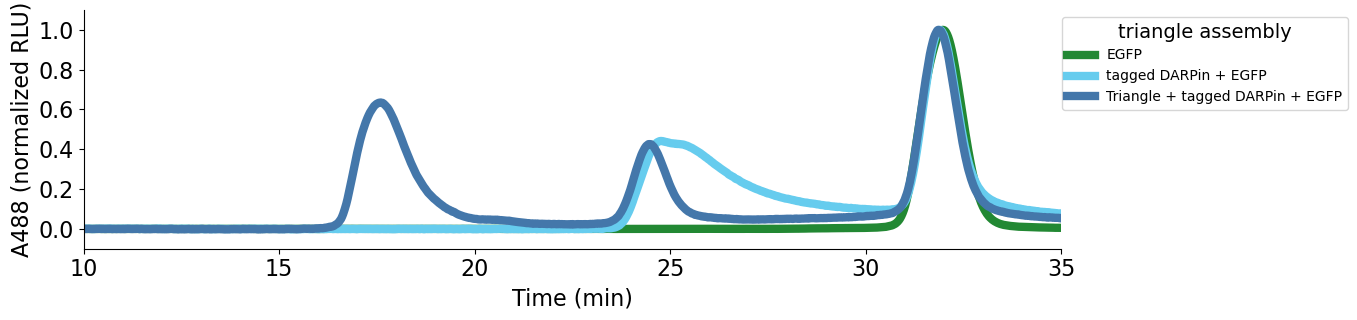

In [77]:
df_triangle_488 = df_triangle[df_triangle['abs_wl'] == 'A488']
triangle_samples_488 = ['EGFP', 'ligand_D2_3G124_mCherry__EGFP15uM', 'ligand_D2_3G124_mCherry__Arm__EGFP15uM']

df_triangle_488 = df_triangle_488[df_triangle_488['sample_name'].isin(triangle_samples_488)]

plt.figure(figsize=(14, 3.3))
ax = plt.subplot(111)
# Iterate over each unique (datetime, sample_name) combination
# Iterate over each unique (datetime, sample_name) combination
for sample_name in triangle_samples_488:  # Iterate in the order defined by sample_list
    sample_run_data = df_triangle_488[df_triangle_488['sample_name'] == sample_name]
    label = sample_name_2_label[sample_name]
    color = tuple(c / 255 for c in triangle_sample_colors[sample_name])  # Normalize RGB values to [0, 1]
    
    # Plot the curve
    ax.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6, color=color)

ax.set_xlabel("Time (min)", fontsize=16)
ax.set_ylabel("A488 (normalized RLU)", fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Add legend with a title
handles, labels = ax.get_legend_handles_labels()
if handles:
    legend = ax.legend(handles, labels, fontsize=10, loc='upper right', bbox_to_anchor=(1.3, 1), title="triangle assembly")
    legend.get_title().set_fontsize(14)  # Set the title font size
plt.grid(False)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.ylim(-0.1, 1.1)  # Retain existing y-limits
plt.xlim(10, 35)     # Retain existing x-limits
plt.savefig('./output/sec_plot_triangle_assembly_488.pdf', format='pdf')
plt.show()

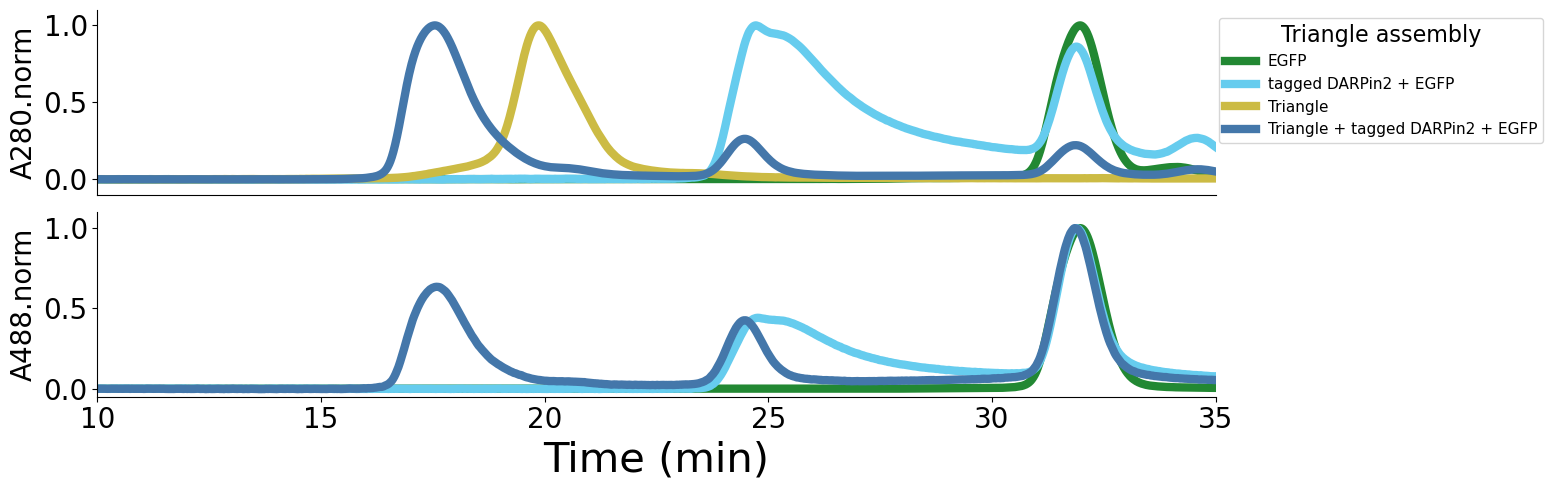

In [81]:
plt.figure(figsize=(16, 5))

fontsize = 20

triangle_samples_280 = ['EGFP', 'ligand_D2_3G124_mCherry__EGFP15uM', 'dArmRP_triangle_5uM', 
               'ligand_D2_3G124_mCherry__Arm__EGFP15uM']

triangle_samples_488 = ['EGFP', 'ligand_D2_3G124_mCherry__EGFP15uM', 'ligand_D2_3G124_mCherry__Arm__EGFP15uM']

# First subplot for A280
ax1 = plt.subplot(211)  # 2 rows, 1 column, first plot
for sample_name in triangle_samples_280:  # Iterate in the order defined by sample_list
    sample_run_data = df_triangle_280[df_triangle_280['sample_name'] == sample_name]
    label = sample_name_2_label[sample_name]
    color = tuple(c / 255 for c in triangle_sample_colors[sample_name])  # Normalize RGB values to [0, 1]
    
    ax1.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6, color=color)

ax1.set_ylabel("A280.norm", fontsize=fontsize)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
handles, labels = ax1.get_legend_handles_labels()
if handles:
    legend = ax1.legend(handles, labels, fontsize=11, loc='upper right', bbox_to_anchor=(1.3, 1), title="Triangle assembly")
    legend.get_title().set_fontsize(fontsize*0.8)  # Set the title font size
ax1.grid(False)
ax1.set_xlim(10, 35)
ax1.set_ylim(-0.1, 1.1)
ax1.set_xticks([])  # Remove x-axis ticks
ax1.set_xlabel("")  # Remove x-axis label

# Second subplot for A488
ax2 = plt.subplot(212)  # 2 rows, 1 column, second plot
for sample_name in triangle_samples_488:  # Iterate in the order defined by triangle_samples_488
    sample_run_data = df_triangle_488[df_triangle_488['sample_name'] == sample_name]
    label = sample_name_2_label[sample_name]
    color = tuple(c / 255 for c in triangle_sample_colors[sample_name])  # Normalize RGB values to [0, 1]
    
    ax2.plot(sample_run_data['time'], sample_run_data['signal_norm'], label=label, lw=6, color=color)

ax2.set_xlabel("Time (min)", fontsize=fontsize*1.5)
ax2.set_ylabel("A488.norm", fontsize=fontsize)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(False)
ax2.set_xlim(10, 35)
ax2.set_ylim(-0.05, 1.1)
ax2.legend().remove()  # Remove the legend

ax1.tick_params(axis='y', labelsize=fontsize)
ax2.tick_params(axis='y', labelsize=fontsize)
ax2.tick_params(axis='x', labelsize=fontsize)
plt.tight_layout()
plt.savefig('./output/sec_plot_triangle_assembly_combined.pdf', format='pdf')
plt.show()


In [107]:
df_triangle = df_processed[df_processed['sample_name'].isin(triangle_samples)]
df_triangle

,datetime,abs_wl,sample_name,time,signal,signal_norm
342036,2022-01-12 13:53:16,A214,EGFP,0.001250,-0.233650,-0.000228
342037,2022-01-12 13:53:16,A214,EGFP,0.007917,-0.185013,-0.000181
342038,2022-01-12 13:53:16,A214,EGFP,0.014583,0.036240,0.000035
342039,2022-01-12 13:53:16,A214,EGFP,0.021250,0.076771,0.000075
342040,2022-01-12 13:53:16,A214,EGFP,0.027917,-0.023842,-0.000023
...,...,...,...,...,...,...
44226322,2023-07-26 16:29:49,A587,dArmRP_triangle__KRKRARQRKRKR_D2__EGFP,74.973333,-0.729561,-0.015897
44226323,2023-07-26 16:29:49,A587,dArmRP_triangle__KRKRARQRKRKR_D2__EGFP,74.980000,-0.730991,-0.015928
44226324,2023-07-26 16:29:49,A587,dArmRP_triangle__KRKRARQRKRKR_D2__EGFP,74.986667,-0.733852,-0.015991
44226325,2023-07-26 16:29:49,A587,dArmRP_triangle__KRKRARQRKRKR_D2__EGFP,74.993333,-0.735283,-0.016022


In [182]:
unique_sample_names = df_processed[df_processed['datetime'].dt.date == pd.to_datetime('2023-07-18').date()]['sample_name'].unique()
unique_sample_names

array(['KRKRARQRKRKR_D2_3G124_mCherry__Arm125',
       'KRKRARQRKRKR_D2_3G124_mCherry__Arm63',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm2000',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm1000',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm500',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm250',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm125',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm63', 'dArmRP_triangle_5uM',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm15uM',
       'KRKRARQRKRKR_D1_3G124_mCherry__Arm15uM',
       'KRKRARQRKRKR_D2_3G124_mCherry__Arm15uM',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm8uM',
       'KRKRARQRKRKR_D1_3G124_mCherry__Arm8uM',
       'KRKRARQRKRKR_D2_3G124_mCherry__Arm8uM',
       'KRKRARQRKRKR_BD_3G124_mCherry__Arm4uM',
       'KRKRARQRKRKR_D1_3G124_mCherry__Arm4uM',
       'KRKRARQRKRKR_D2_3G124_mCherry__Arm4uM'], dtype=object)